In [1]:
import torch
import torch.nn as nn
import torchvision
import tqdm
import time
import matplotlib.pyplot as plt


torch.manual_seed(42)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"


In [2]:
transformers = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(), torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
training_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transformers)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transformers)

In [3]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_c, out_c, stride=1, ks=3, padding=1, use_bn=False):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size=ks, stride=stride, padding=padding, bias=False)
        self.bn   = nn.BatchNorm2d(out_c) if use_bn else nn.Identity()
        self.act  = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.act(out)

        return out

def make_stage(in_c, out_c, num_blocks, first_stride):
    blocks = []
    for i in range(num_blocks):
        stride = first_stride if i == 0 else 1
        c_in   = in_c if i == 0 else out_c
        blocks.append(ConvBNReLU(c_in, out_c, stride=stride))
    return nn.Sequential(*blocks)

class Plain20CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = ConvBNReLU(3, 16, stride=1)

        self.stage1 = make_stage(16, 16, num_blocks=6, first_stride=1)
        self.stage2 = make_stage(16, 32, num_blocks=6, first_stride=2)
        self.stage3 = make_stage(32, 64, num_blocks=6, first_stride=2)

        self.gap = nn.AdaptiveAvgPool2d(4)
        self.fc  = nn.Linear(64 * 4 * 4, 10)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x).flatten(1)
        return self.fc(x)


In [4]:
def validate(model, val_loader, criterion, device):
    model.eval()
    correct = 0
    total_loss = 0
    total_items = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total_items += labels.size(0)
            total_loss += loss.item()

    acc = correct / total_items
    avg_loss = total_loss / len(val_loader)
    return avg_loss, acc

In [5]:
def capture_gradient_magnitude(model: Plain20CNN):
    # Calculate total layers: stem + all stages
    total_layers = 1 + len(model.stage1) + len(model.stage2) + len(model.stage3)
    output = torch.zeros(total_layers)
    
    idx = 0
    
    # Stem
    if model.stem.conv.weight.grad is not None:
        num_elements = model.stem.conv.weight.grad.numel()
        output[idx] = torch.norm(model.stem.conv.weight.grad) / num_elements
    idx += 1
    
    # Stage1
    for i in range(len(model.stage1)):
        if model.stage1[i].conv.weight.grad is not None:
            num_elements = model.stage1[i].conv.weight.grad.numel()
            output[idx] = torch.norm(model.stage1[i].conv.weight.grad) / num_elements
        idx += 1
    
    # Stage2
    for i in range(len(model.stage2)):
        if model.stage2[i].conv.weight.grad is not None:
            num_elements = model.stage2[i].conv.weight.grad.numel()
            output[idx] = torch.norm(model.stage2[i].conv.weight.grad) / num_elements
        idx += 1
    
    # Stage3
    for i in range(len(model.stage3)):
        if model.stage3[i].conv.weight.grad is not None:
            num_elements = model.stage3[i].conv.weight.grad.numel()
            output[idx] = torch.norm(model.stage3[i].conv.weight.grad) / num_elements
        idx += 1
    
    return output

In [6]:

def train_with_validation(model, train_loader, val_loader, optimizer, criterion, scheduler, grad_caputrer, device, epochs=20):
    model = model.to(device)

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    # FIXED: Get actual layer count from gradient capture function
    # Run a dummy forward/backward to determine the actual number of layers
    dummy_input = torch.randn(1, 3, 32, 32).to(device)
    dummy_output = model(dummy_input)
    dummy_loss = dummy_output.sum()
    dummy_loss.backward()
    
    # Get the actual number of layers from gradient capture
    dummy_grad_mag = grad_caputrer(model)
    total_layers = dummy_grad_mag.shape[0]
    
    # Clear gradients after dummy run
    optimizer.zero_grad()
    
    print(f"Detected {total_layers} layers for gradient tracking")
    
    grads_magnitudes = torch.zeros((epochs, total_layers))

    for epoch in range(epochs):
        # Training
        model.train()
        correct = 0
        total_loss = 0
        total_items = 0

        print(f"Epoch {epoch + 1}/{epochs}")
        start_time = time.time()
        cumulative_grad_magnitudes = torch.zeros((len(train_loader), total_layers))
        batch_number = 0
        for images, labels in tqdm.tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            grad_mag = grad_caputrer(model)
            cumulative_grad_magnitudes[batch_number] = grad_mag
            optimizer.step()

            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total_items += labels.size(0)
            total_loss += loss.item()
            batch_number += 1

        grads_magnitudes[epoch] = cumulative_grad_magnitudes.mean(0)
        train_acc = correct / total_items
        train_loss = total_loss / len(train_loader)

        # Validation
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        # Step the scheduler
        scheduler.step()

        # Store metrics
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        total_time = time.time() - start_time

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print(f"Time: {total_time:.2f}s\n")

    return train_losses, train_accs, val_losses, val_accs, grads_magnitudes

In [7]:
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    training_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
)


In [8]:
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')


# After creating model:
model = Plain20CNN()
#model.apply(init_weights)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

train_losses, train_accs, val_losses, val_accs, grads_magnitudes = train_with_validation(model, train_loader, test_loader, optimizer, criterion, scheduler, capture_gradient_magnitude, device, epochs=10)

Epoch 1/10


Training:   0%|          | 0/782 [00:00<?, ?it/s]/Users/diego.nava/PycharmProjects/practiceudl/venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training: 100%|██████████| 782/782 [00:28<00:00, 27.69it/s]


Train Loss: 2.3061, Train Acc: 0.1011
Val Loss: 2.3045, Val Acc: 0.1000
Time: 42.14s

Epoch 2/10


Training: 100%|██████████| 782/782 [00:28<00:00, 27.65it/s]


Train Loss: 2.3067, Train Acc: 0.0999
Val Loss: 2.3070, Val Acc: 0.1000
Time: 42.00s

Epoch 3/10


...

Train Loss: 2.3060, Train Acc: 0.1002
Val Loss: 2.3055, Val Acc: 0.1000
Time: 41.62s

Epoch 9/10


Training: 100%|██████████| 782/782 [00:28<00:00, 27.91it/s]


Train Loss: 2.3066, Train Acc: 0.0997
Val Loss: 2.3062, Val Acc: 0.1000
Time: 41.78s

Epoch 10/10


Training: 100%|██████████| 782/782 [00:27<00:00, 27.96it/s]


Train Loss: 2.3061, Train Acc: 0.1021
Val Loss: 2.3071, Val Acc: 0.1000
Time: 41.91s



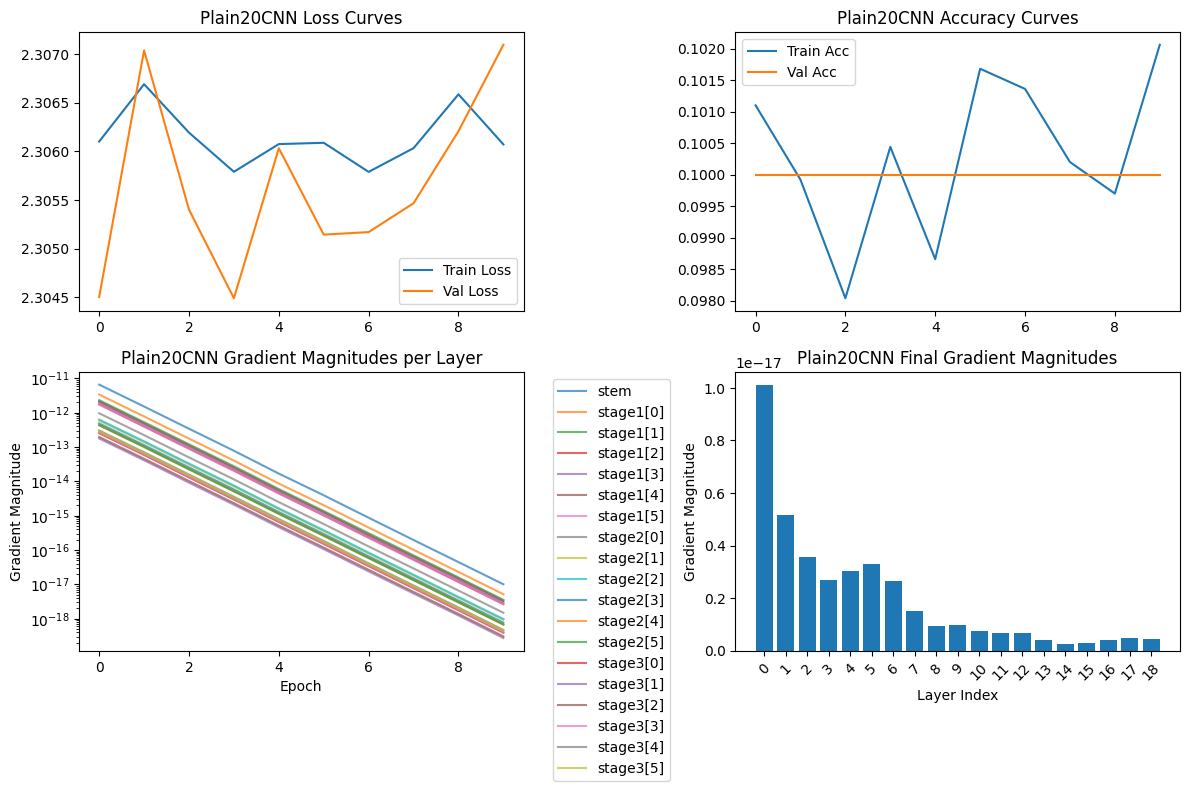

In [9]:

# Plot Plain20CNN training curves (FIRST PLOT - after Plain20CNN training)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Loss curves
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Plain20CNN Loss Curves')  # Fixed title
ax1.legend()

# Accuracy curves
ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Plain20CNN Accuracy Curves')  # Fixed title
ax2.legend()

# CORRECT layer names for Plain20CNN (19 layers: 1 + 6 + 6 + 6)
plain_layer_names = ['stem'] + [f'stage1[{i}]' for i in range(6)] + [f'stage2[{i}]' for i in range(6)] + [f'stage3[{i}]' for i in range(6)]

# Gradient magnitudes over time (using PLAIN20CNN data and labels)
for i in range(grads_magnitudes.shape[1]):
    ax3.plot(grads_magnitudes[:, i], label=plain_layer_names[i], alpha=0.7)
ax3.set_title('Plain20CNN Gradient Magnitudes per Layer')  # Fixed title
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Gradient Magnitude')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.set_yscale('log')

# Final gradient magnitudes (using PLAIN20CNN data)
ax4.bar(range(grads_magnitudes.shape[1]), grads_magnitudes[-1])
ax4.set_title('Plain20CNN Final Gradient Magnitudes')  # Fixed title
ax4.set_xlabel('Layer Index')
ax4.set_ylabel('Gradient Magnitude')
ax4.set_xticks(range(grads_magnitudes.shape[1]))
ax4.set_xticklabels([f'{i}' for i in range(grads_magnitudes.shape[1])], rotation=45)

plt.tight_layout()
plt.show()

In [8]:
def capture_gradient_magnitude_resnet(model):
    """Capture gradients for ResNet including shortcut convolutions"""
    # Calculate layers: stem + (3 stages × 3 blocks × 2 conv each) + 2 shortcut convs
    total_layers = 1 + 3 * 3 * 2 + 2  # = 21 conv layers
    output = torch.zeros(total_layers)
    
    idx = 0
    
    # Stem
    if hasattr(model.stem, 'conv') and model.stem.conv.weight.grad is not None:
        num_elements = model.stem.conv.weight.grad.numel()
        output[idx] = torch.norm(model.stem.conv.weight.grad) / num_elements
    idx += 1
    
    # Stages (each block has 2 conv layers + potential shortcut)
    for stage in [model.stage1, model.stage2, model.stage3]:
        for block in stage:
            # First conv in block
            if block.conv1.weight.grad is not None:
                num_elements = block.conv1.weight.grad.numel()
                output[idx] = torch.norm(block.conv1.weight.grad) / num_elements
            idx += 1
            
            # Second conv in block
            if block.conv2.weight.grad is not None:
                num_elements = block.conv2.weight.grad.numel()
                output[idx] = torch.norm(block.conv2.weight.grad) / num_elements
            idx += 1
            
            # Check for shortcut conv
            if (hasattr(block.shortcut, '0') and 
                isinstance(block.shortcut[0], nn.Conv2d) and 
                block.shortcut[0].weight.grad is not None):
                num_elements = block.shortcut[0].weight.grad.numel()
                output[idx] = torch.norm(block.shortcut[0].weight.grad) / num_elements
                idx += 1
    
    return output

In [43]:
class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1, ks=3, padding=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, ks, stride=stride, padding=padding, bias=False)
        self.bn1   = nn.BatchNorm2d(in_c, momentum=0.4)
        self.conv2 = nn.Conv2d(out_c, out_c, ks, stride=1, padding=padding, bias=False)
        self.bn2   = nn.BatchNorm2d(out_c, momentum=0.4)
        self.act   = nn.ReLU(inplace=True)

        self.shortcut = (
            nn.Identity() if (stride == 1 and in_c == out_c)
            else nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c)
            )
        )


    def forward(self, x):
        identity = self.shortcut(x)
        #out = self.act(self.bn1(self.conv1(x)))
        #out = self.bn2(self.conv2(out))
        out = self.conv1(self.act(self.bn1(x)))   # BN → ReLU → Conv
        out = self.conv2(self.act(self.bn2(out))) # BN → ReLU → Conv
        return out + identity


def make_stage(in_c, out_c, num_blocks, first_stride):
    blocks = []
    for i in range(num_blocks):
        stride = first_stride if i == 0 else 1
        c_in   = in_c if i == 0 else out_c
        blocks.append(BasicBlock(c_in, out_c, stride=stride))
    return nn.Sequential(*blocks)

class Resnet20CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16)
        )

        self.stem = ConvBNReLU(3, 16, stride=1, use_bn=True)

        self.stage1 = make_stage(16, 16, num_blocks=3, first_stride=1)
        self.stage2 = make_stage(16, 32, num_blocks=3, first_stride=2)
        self.stage3 = make_stage(32, 64, num_blocks=3, first_stride=2)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(64, 10)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x).flatten(1)
        return self.fc(x)


In [44]:
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        pass
        #nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

resnet_model = Resnet20CNN()
resnet_model.apply(init_weights)

resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = torch.optim.SGD(resnet_model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
resnet_scheduler = torch.optim.lr_scheduler.StepLR(resnet_optimizer, step_size=10, gamma=0.1)

resnet_train_losses, resnet_train_accs, resnet_val_losses, resnet_val_accs, resnet_grads = train_with_validation(
    resnet_model, train_loader, test_loader, resnet_optimizer, resnet_criterion, resnet_scheduler, 
    capture_gradient_magnitude_resnet, device, epochs=24
)

torch.save(resnet_model.state_dict(), 'resnet_pre_act_sgd_weights.pth')

print("SGD model saved to disk")


Detected 21 layers for gradient tracking
Epoch 1/24


Training: 100%|██████████| 782/782 [00:36<00:00, 21.70it/s]


Train Loss: 1.6003, Train Acc: 0.4011
Val Loss: 1.3479, Val Acc: 0.4978
Time: 50.63s

Epoch 2/24


Training: 100%|██████████| 782/782 [00:36<00:00, 21.70it/s]


Train Loss: 1.1390, Train Acc: 0.5923
Val Loss: 1.1046, Val Acc: 0.6194
Time: 50.99s

Epoch 3/24


...

Train Loss: 0.0248, Train Acc: 0.9948
Val Loss: 0.7523, Val Acc: 0.8426
Time: 52.13s

Epoch 23/24


Training: 100%|██████████| 782/782 [00:40<00:00, 19.33it/s]


Train Loss: 0.0231, Train Acc: 0.9952
Val Loss: 0.7338, Val Acc: 0.8404
Time: 55.42s

Epoch 24/24


Training: 100%|██████████| 782/782 [00:37<00:00, 20.79it/s]


Train Loss: 0.0205, Train Acc: 0.9957
Val Loss: 0.7362, Val Acc: 0.8454
Time: 52.80s

SGD model saved to disk


In [21]:
# Fine tune with adam to see if we can improve performance
resnet_model = Resnet20CNN()
resnet_model.load_state_dict(torch.load('resnet_sgd_weights.pth'))
resnet_model.to(device)

adam_optimizer = torch.optim.Adam(
    resnet_model.parameters(),
    lr=0.0005,
    weight_decay=3e-3
)
resnet_scheduler = torch.optim.lr_scheduler.StepLR(resnet_optimizer, step_size=5, gamma=0.3)

resnet_train_losses, resnet_train_accs, resnet_val_losses, resnet_val_accs, resnet_grads = train_with_validation(
    resnet_model, train_loader, test_loader, adam_optimizer, resnet_criterion, resnet_scheduler,
    capture_gradient_magnitude_resnet, device, epochs=16
)


Detected 21 layers for gradient tracking
Epoch 1/16


Training: 100%|██████████| 782/782 [00:39<00:00, 19.76it/s]


Train Loss: 0.0853, Train Acc: 0.9718
Val Loss: 0.5858, Val Acc: 0.8324
Time: 54.10s

Epoch 2/16


Training: 100%|██████████| 782/782 [00:39<00:00, 19.81it/s]


Train Loss: 0.1318, Train Acc: 0.9558
Val Loss: 0.5230, Val Acc: 0.8395
Time: 53.87s

Epoch 3/16


...

Train Loss: 0.2056, Train Acc: 0.9338
Val Loss: 0.5859, Val Acc: 0.8137
Time: 54.01s

Epoch 15/16


Training: 100%|██████████| 782/782 [00:39<00:00, 19.77it/s]


Train Loss: 0.2067, Train Acc: 0.9338
Val Loss: 0.5767, Val Acc: 0.8215
Time: 54.57s

Epoch 16/16


Training: 100%|██████████| 782/782 [00:39<00:00, 19.88it/s]


Train Loss: 0.2070, Train Acc: 0.9347
Val Loss: 0.5749, Val Acc: 0.8169
Time: 54.39s



Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x10a14fe50>
Traceback (most recent call last):
  File "/Users/diego.nava/PycharmProjects/practiceudl/venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/Users/diego.nava/PycharmProjects/practiceudl/venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1622, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


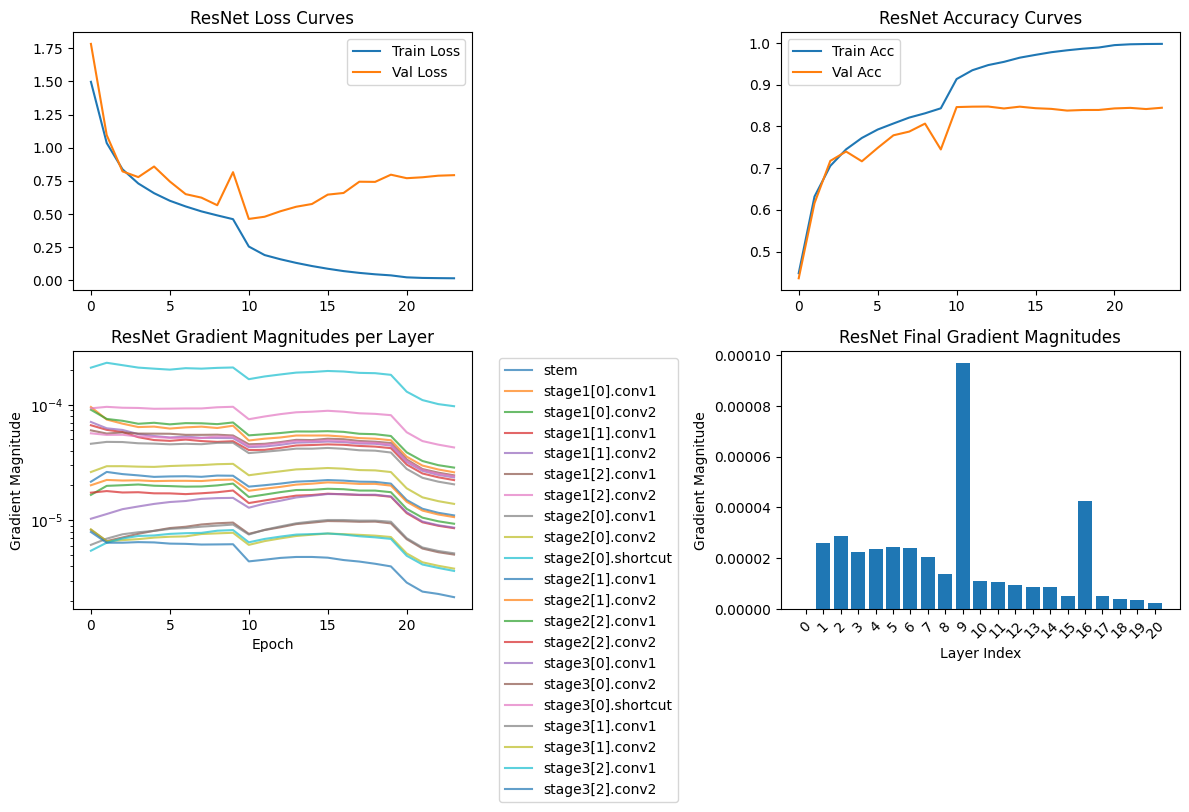

In [33]:
# Plot ResNet training curves (using resnet_* variables)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Loss curves
ax1.plot(resnet_train_losses, label='Train Loss')
ax1.plot(resnet_val_losses, label='Val Loss')
ax1.set_title('ResNet Loss Curves')
ax1.legend()

# Accuracy curves
ax2.plot(resnet_train_accs, label='Train Acc')
ax2.plot(resnet_val_accs, label='Val Acc')
ax2.set_title('ResNet Accuracy Curves')
ax2.legend()

# ResNet layer names (21 conv layers including shortcuts)
resnet_layer_names = ['stem']
for stage_idx in range(3):
    for block_idx in range(3):
        resnet_layer_names.append(f'stage{stage_idx+1}[{block_idx}].conv1')
        resnet_layer_names.append(f'stage{stage_idx+1}[{block_idx}].conv2')
        # Add shortcut conv names for first block of stage2 and stage3
        if stage_idx > 0 and block_idx == 0:
            resnet_layer_names.append(f'stage{stage_idx+1}[{block_idx}].shortcut')

# Gradient magnitudes over time (using resnet_grads)
for i in range(resnet_grads.shape[1]):
    ax3.plot(resnet_grads[:, i], label=resnet_layer_names[i], alpha=0.7)
ax3.set_title('ResNet Gradient Magnitudes per Layer')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Gradient Magnitude')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.set_yscale('log')

# Final gradient magnitudes (using resnet_grads)
ax4.bar(range(resnet_grads.shape[1]), resnet_grads[-1])
ax4.set_title('ResNet Final Gradient Magnitudes')
ax4.set_xlabel('Layer Index')
ax4.set_ylabel('Gradient Magnitude')
ax4.set_xticks(range(resnet_grads.shape[1]))
ax4.set_xticklabels([f'{i}' for i in range(resnet_grads.shape[1])], rotation=45)

plt.tight_layout()
plt.show()